In [1]:
import numpy as np
import pandas as pd






Data Loading and cleaning

In [2]:
df=pd.read_csv("../datasets/Data_Entry_2017.csv",delimiter=",")
print(df.head())

        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   
3  00000002_000.png              No Finding            0           2   
4  00000003_000.png                  Hernia            0           3   

  Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0        058Y              M            PA                 2682     2749   
1        058Y              M            PA                 2894     2729   
2        058Y              M            PA                 2500     2048   
3        081Y              M            PA                 2500     2048   
4        081Y              F            PA                 2582     2991   

   OriginalImagePixelSpacing[x     y]  Unnamed: 11  
0                        0.143  0.143          NaN  
1   

In [3]:
df.drop(columns=["Unnamed: 11"],inplace=True)
print(df.head())

        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   
3  00000002_000.png              No Finding            0           2   
4  00000003_000.png                  Hernia            0           3   

  Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0        058Y              M            PA                 2682     2749   
1        058Y              M            PA                 2894     2729   
2        058Y              M            PA                 2500     2048   
3        081Y              M            PA                 2500     2048   
4        081Y              F            PA                 2582     2991   

   OriginalImagePixelSpacing[x     y]  
0                        0.143  0.143  
1                        0.143

In [4]:
df.isnull().sum()

Image Index                    0
Finding Labels                 0
Follow-up #                    0
Patient ID                     0
Patient Age                    0
Patient Gender                 0
View Position                  0
OriginalImage[Width            0
Height]                        0
OriginalImagePixelSpacing[x    0
y]                             0
dtype: int64

Label Encoding

In [5]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df["Patient Gender"]=le.fit_transform(df["Patient Gender"])
df["View Position"]=le.fit_transform(df["View Position"])

In [6]:
print(df.head())

        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   
3  00000002_000.png              No Finding            0           2   
4  00000003_000.png                  Hernia            0           3   

  Patient Age  Patient Gender  View Position  OriginalImage[Width  Height]  \
0        058Y               1              1                 2682     2749   
1        058Y               1              1                 2894     2729   
2        058Y               1              1                 2500     2048   
3        081Y               1              1                 2500     2048   
4        081Y               0              1                 2582     2991   

   OriginalImagePixelSpacing[x     y]  
0                        0.143  0.143  
1                 

In [7]:
df['Finding Labels'] = df['Finding Labels'].astype(str)
print(df["Finding Labels"].dtype)

str


In [8]:
all_labels = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration',
    'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax',
    'Consolidation', 'Edema', 'Emphysema',
    'Fibrosis', 'Pleural_Thickening', 'Hernia'
]

def encode_labels(label_str):
    if label_str == "No Finding":
        return [0] * len(all_labels)

    label_list = label_str.split('|')
    return [1 if label in label_list else 0 for label in all_labels]


In [9]:
df['encoded_labels'] = df['Finding Labels'].apply(encode_labels)

In [10]:
import torch

label = df.iloc[0]['encoded_labels']
label = torch.tensor(label, dtype=torch.float32)

print(label)


tensor([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


In [11]:
def convert_age(x):
    x = str(x)

    if "Y" in x:
        return int(x.replace("Y", ""))
    elif "M" in x:
        return int(x.replace("M", "")) / 12  # convert months → years
    else:
        return None

df["Patient Age"] = df["Patient Age"].apply(convert_age)

In [12]:
print(df.head(5))


        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   
3  00000002_000.png              No Finding            0           2   
4  00000003_000.png                  Hernia            0           3   

   Patient Age  Patient Gender  View Position  OriginalImage[Width  Height]  \
0         58.0               1              1                 2682     2749   
1         58.0               1              1                 2894     2729   
2         58.0               1              1                 2500     2048   
3         81.0               1              1                 2500     2048   
4         81.0               0              1                 2582     2991   

   OriginalImagePixelSpacing[x     y]  \
0                        0.143  0.143   
1         

In [13]:
img_dir="../datasets/images-224/images-224/"

In [14]:
from torch.utils.data import Dataset
class ChestXrayDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        import os
        from PIL import Image
        import torch

        filename = self.df.iloc[idx]['Image Index'].strip()
        img_path = os.path.join(self.img_dir, filename)

        image = Image.open(img_path).convert("RGB")

        label = torch.tensor(
            self.df.iloc[idx]['encoded_labels'],
            dtype=torch.float32
        )

        if self.transform:
            image = self.transform(image)

        return image, label

In [15]:
scaler = torch.cuda.amp.GradScaler()



C:\Users\User\AppData\Local\Temp\ipykernel_24144\408380278.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [16]:
import torchvision
print(torch.__version__)


2.11.0+cu128


In [17]:
import torchvision.transforms as transforms
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
])

In [18]:
from torch.utils.data import DataLoader,random_split
from torch.utils.data import random_split
dataset = ChestXrayDataset(df, img_dir, transform)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset,    [train_size, val_size])


In [19]:
print(ChestXrayDataset)
print(type(ChestXrayDataset))

<class '__main__.ChestXrayDataset'>
<class 'type'>


In [20]:
print(type(ChestXrayDataset))

<class 'type'>


In [21]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=32,shuffle=False)

In [22]:
import torchvision.models as models
import torch.nn as nn
model=models.densenet121(weights="IMAGENET1K_V1")
for params in model.features.parameters():
    params.requires_grad = False

model.classifier = nn.Linear(1024,14)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model=model.to(device)

In [23]:
import torch.nn as nn
import torch.optim as optim
criterion=nn.BCEWithLogitsLoss()
optimizer=optim.Adam(model.parameters(),lr=1e-3)

In [24]:
import sys
print(sys.version)

3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]


In [25]:

torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')

model = model.to(device)

scaler = torch.cuda.amp.GradScaler()

model.train()

epochs = 10

for epoch in range(epochs):

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast():

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        predicted = torch.sigmoid(outputs)
        predicted = (predicted > 0.5).float()

        correct += (predicted == labels).sum().item()
        total += labels.numel()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    print(
        f"Epoch[{epoch+1}/{epochs}] | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_acc:.2f}%"
    )

C:\Users\User\AppData\Local\Temp\ipykernel_24144\1940495413.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
C:\Users\User\AppData\Local\Temp\ipykernel_24144\1940495413.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch[1/10] | Loss: 0.1733 | Accuracy: 94.81%
Epoch[2/10] | Loss: 0.1687 | Accuracy: 94.83%
Epoch[3/10] | Loss: 0.1678 | Accuracy: 94.82%
Epoch[4/10] | Loss: 0.1676 | Accuracy: 94.82%
Epoch[5/10] | Loss: 0.1672 | Accuracy: 94.81%
Epoch[6/10] | Loss: 0.1670 | Accuracy: 94.82%
Epoch[7/10] | Loss: 0.1670 | Accuracy: 94.82%
Epoch[8/10] | Loss: 0.1668 | Accuracy: 94.81%
Epoch[9/10] | Loss: 0.1666 | Accuracy: 94.81%
Epoch[10/10] | Loss: 0.1667 | Accuracy: 94.81%


In [26]:

print(next(model.parameters()).device)

cuda:0


In [27]:
torch.save(model.state_dict(),"x-ray-model.pth")

Validation

In [28]:
model.eval()

correct = 0
total = 0
val_loss = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        val_loss += loss.item()

        predictions = torch.sigmoid(outputs)

        predictions = (predictions > 0.5).float()

        correct += (predictions == labels).sum().item()

        total += labels.numel()

val_acc = 100 * correct / total

avg_loss = val_loss / len(val_loader)

print(f"Validation Accuracy: {val_acc:.2f}%")
print(f"Validation Loss: {avg_loss:.4f}")

Validation Accuracy: 94.78%
Validation Loss: 0.1685


Metrices


In [29]:
from sklearn.metrics import confusion_matrix

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)


        preds = torch.argmax(outputs, dim=1)


        labels = torch.argmax(labels, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

print(cm)



[[3183  343  931 8088  872  477    0  422    8    0   22    5    1    0]
 [  71   76   40  240   22    5    0    8    0    0    0    0    0    0]
 [ 339   15  493  852   85   28    0   90    2    0    3    0    0    0]
 [ 378   69  173 1841  108   73    0   76    2    0    6    0    0    0]
 [ 128    7   49  271  118   41    0   36    0    0    3    1    0    1]
 [  98   12   35  344   63   59    0   26    0    0    1    2    0    0]
 [  15    1    6   62    1    1    0    2    0    0    0    0    0    0]
 [  98    4   64  218   30    6    0  120    0    0    7    3    0    0]
 [  40    3   22  199   10    3    0    5    0    0    0    0    0    0]
 [  14    2   14   99    3    0    0    2    0    0    1    0    0    0]
 [  50    1    5   94   22   11    0   26    0    0    2    0    0    0]
 [  26    5    9   79   16   19    0    9    0    0    0    0    0    0]
 [  39    1   30  118   18   11    0   14    0    0    0    0    0    0]
 [   7    2    0    8    3    2    0    0    0    0

In [30]:
print("Confusion Matrix:\n")
print(cm)

Confusion Matrix:

[[3183  343  931 8088  872  477    0  422    8    0   22    5    1    0]
 [  71   76   40  240   22    5    0    8    0    0    0    0    0    0]
 [ 339   15  493  852   85   28    0   90    2    0    3    0    0    0]
 [ 378   69  173 1841  108   73    0   76    2    0    6    0    0    0]
 [ 128    7   49  271  118   41    0   36    0    0    3    1    0    1]
 [  98   12   35  344   63   59    0   26    0    0    1    2    0    0]
 [  15    1    6   62    1    1    0    2    0    0    0    0    0    0]
 [  98    4   64  218   30    6    0  120    0    0    7    3    0    0]
 [  40    3   22  199   10    3    0    5    0    0    0    0    0    0]
 [  14    2   14   99    3    0    0    2    0    0    1    0    0    0]
 [  50    1    5   94   22   11    0   26    0    0    2    0    0    0]
 [  26    5    9   79   16   19    0    9    0    0    0    0    0    0]
 [  39    1   30  118   18   11    0   14    0    0    0    0    0    0]
 [   7    2    0    8    3    2 

In [31]:
from sklearn.metrics import classification_report
print("Classification Report:\n")
print(classification_report(all_labels, all_preds))

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.22      0.34     14352
           1       0.14      0.16      0.15       462
           2       0.26      0.26      0.26      1907
           3       0.15      0.68      0.24      2726
           4       0.09      0.18      0.12       655
           5       0.08      0.09      0.09       640
           6       0.00      0.00      0.00        88
           7       0.14      0.22      0.17       550
           8       0.00      0.00      0.00       282
           9       0.00      0.00      0.00       135
          10       0.04      0.01      0.02       211
          11       0.00      0.00      0.00       163
          12       0.00      0.00      0.00       231
          13       0.00      0.00      0.00        22

    accuracy                           0.26     22424
   macro avg       0.12      0.13      0.10     22424
weighted avg       0.51      0.26      0.28     22424



C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

Prediction on a new image

In [32]:
model.load_state_dict(torch.load("x-ray-model.pth"))
model.eval()
model = model.to(device)

In [33]:
from PIL import Image
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [134]:
image = Image.open("../datasets/images-224/images-224/00023566_000.png").convert("RGB")
image = transform(image)

image=image.unsqueeze(0).to(device)                 # now convert


In [135]:

diseases = [
    "Atelectasis",
    "Cardiomegaly",
    "Effusion",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pneumonia",
    "Pneumothorax"
]

In [136]:
with torch.no_grad():
    outputs = model(image)

    probs = torch.sigmoid(outputs)

In [137]:
normalized = probs / probs.sum()

for i in range(len(diseases)):
    print(f"{diseases[i]}: {normalized[0][i].item()*100:.2f}%")

Atelectasis: 7.37%
Cardiomegaly: 1.06%
Effusion: 6.75%
Infiltration: 34.32%
Mass: 8.81%
Nodule: 16.03%
Pneumonia: 2.40%
Pneumothorax: 5.07%


In [138]:
threshold = 0.15

for i, prob in enumerate(probs[0]):
    if prob > threshold:
        print(f"{diseases[i]}: {prob.item()*100:.2f}%")

In [139]:
top_probs, top_idx = torch.topk(probs, k=3)

for i in range(3):
    print(
        f"{diseases[top_idx[0][i]]}: {top_probs[0][i].item()*100:.2f}%"
    )

Infiltration: 9.77%
Nodule: 4.56%
Mass: 2.51%


Infiltration: 9.77%
Nodule: 4.56%
Mass: 2.51%


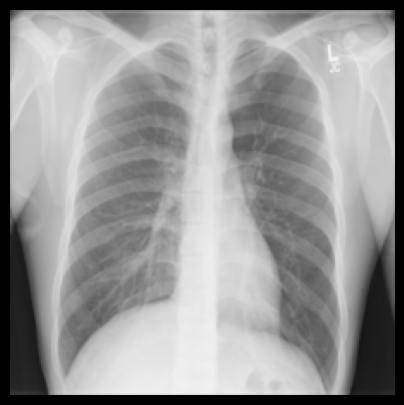

In [140]:
import matplotlib.pyplot as plt

top_probs, top_idx = torch.topk(probs, k=3)

for i in range(3):
    print(
        f"{diseases[top_idx[0][i]]}: {top_probs[0][i].item()*100:.2f}%"
    )

img = image.cpu()                 # move to CPU
img = img.squeeze(0)              # remove batch → [3,224,224]
img = img.permute(1, 2, 0)        # CHW → HWC
img = img.numpy()

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.show()


In [89]:
image.shape

torch.Size([1, 3, 224, 224])